In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('netflix_customer_churn_unstructured.csv')

In [3]:
df

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,Random_Text,Unused_Code,Extra_Column,Fake_Status
0,CUS_971,63,Other,Basic,18.77,56,NaN,Mobile,8.99,1,Crypto,2,0.33,Sci-Fi,trash,45417,abc,yes
1,CUS_2420,37,Female,Basic,25.43,5,Africa,Desktop,8.99,0,Gift Card,4,4.24,Horror,trash,93753,none,no
2,CUS_1860,58,Other,Basic,5.36,59,???,TV,8.99,1,Crypto,1,0.09,Comedy,sample,99047,xyz,no
3,CUS_2697,40,Male,Standard,3.48,29,Oceania,Laptop,13.99,0,Debit Card,4,0.12,Drama,random,26160,xyz,yes
4,CUS_3301,53,Other,Standard,1.55,30,Asia,Laptop,13.99,1,Credit Card,3,0.05,Documentary,sample,44072,temp,maybe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,CUS_2512,21,Other,Standard,3.18,41,Europe,Laptop,13.99,1,PayPal,1,0.08,Documentary,trash,82582,none,no
7496,CUS_4500,28,Other,Basic,0.79,40,Asia,Laptop,8.99,1,Gift Card,1,0.02,Action,dummy,50552,temp,yes
7497,CUS_2295,57,Other,Premium,8.62,40,###,Desktop,17.99,1,PayPal,2,0.21,Romance,trash,81321,none,yes
7498,CUS_861,29,Male,Premium,9.22,6,South America,Laptop,17.99,0,Debit Card,4,1.32,Drama,dummy,63939,temp,yes


In [4]:
df.shape

(7500, 18)

In [5]:
df.columns

Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre', 'Random_Text', 'Unused_Code', 'Extra_Column',
       'Fake_Status'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             7500 non-null   str    
 1   age                     7500 non-null   int64  
 2   gender                  7500 non-null   str    
 3   subscription_type       7500 non-null   str    
 4   watch_hours             7500 non-null   float64
 5   last_login_days         7500 non-null   int64  
 6   region                  6055 non-null   str    
 7   device                  7500 non-null   str    
 8   monthly_fee             7500 non-null   float64
 9   churned                 7500 non-null   int64  
 10  payment_method          7500 non-null   str    
 11  number_of_profiles      7500 non-null   int64  
 12  avg_watch_time_per_day  7500 non-null   float64
 13  favorite_genre          7500 non-null   str    
 14  Random_Text             7500 non-null   str    
 15

In [7]:
df.duplicated().any()

np.True_

In [8]:
df.duplicated().sum()

np.int64(2500)

In [9]:
df['customer_id'].duplicated().any()

np.True_

In [10]:
df['customer_id'].duplicated().sum()

np.int64(2500)

In [11]:
df.isnull().sum()

customer_id                  0
age                          0
gender                       0
subscription_type            0
watch_hours                  0
last_login_days              0
region                    1445
device                       0
monthly_fee                  0
churned                      0
payment_method               0
number_of_profiles           0
avg_watch_time_per_day       0
favorite_genre               0
Random_Text                  0
Unused_Code                  0
Extra_Column                 0
Fake_Status                  0
dtype: int64

In [12]:
df['region'].unique()

<StringArray>
[            nan,        'Africa',           '???',       'Oceania',
          'Asia', 'North America',        'Europe',         'error',
 'South America',           '###',       'unknown',       'invalid']
Length: 12, dtype: str

In [13]:
for col in df.columns:
    print(df[col].unique())

<StringArray>
[ 'CUS_971', 'CUS_2420', 'CUS_1860', 'CUS_2697', 'CUS_3301', 'CUS_3040',
 'CUS_3676', 'CUS_1447', 'CUS_2912', 'CUS_3665',
 ...
 'CUS_3988', 'CUS_4068',  'CUS_957', 'CUS_1649', 'CUS_4500', 'CUS_2512',
 'CUS_4780', 'CUS_3343', 'CUS_3074',  'CUS_035']
Length: 5000, dtype: str
[63 37 58 40 53 45 69 59 35 70 19 33 31 36 61 44 18 39 52 26 20 64 42 30
 46 23 28 22 41 24 27 29 65 43 38 49 67 48 25 55 47 32 21 51 50 68 66 34
 57 54 56 62 60]
<StringArray>
['Other', 'Female', 'Male']
Length: 3, dtype: str
<StringArray>
['Basic', 'Standard', 'Premium']
Length: 3, dtype: str
[18.77 25.43  5.36 ... 32.38 35.97 27.9 ]
[56  5 59 29 30 14  4 49 22 24  1 60 13  3 53 39 54 21 57 12 33 55 32 15
 41 10 38  8 23 35 50 45 34 40 11 20 37 52 46 17 36 27 44 51 26  9  2 28
 18 58 48  0 42 16 25  6  7 43 19 31 47]
<StringArray>
[            nan,        'Africa',           '???',       'Oceania',
          'Asia', 'North America',        'Europe',         'error',
 'South America',           '###', 

In [14]:
df['customer_id'].count()

np.int64(7500)

# observation

1. rows having duplicate customer_id must be removed
2. there is have missing values
3. columns have unwanted values
4. columns are in string data type 
5. datas are not in order
6. Random_Text , Unused_Code, Extra_Column , Fake_Status , is not required

# DATA CLEANING

### 1. remove duplicate rows


In [15]:
df=df.sort_values(by='customer_id')
df=df.reset_index(drop=True)
df
df['customer_id']=df['customer_id'].drop_duplicates()

In [16]:
df

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,Random_Text,Unused_Code,Extra_Column,Fake_Status
0,CUS_001,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,trash,57969,xyz,maybe
1,NaN,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,trash,57969,xyz,maybe
2,CUS_002,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,trash,71646,temp,yes
3,CUS_003,27,Female,Standard,16.32,10,NaN,TV,13.99,0,Crypto,2,1.48,Drama,sample,21939,abc,maybe
4,CUS_004,53,Other,Premium,4.51,12,NaN,TV,17.99,1,Crypto,2,0.35,Horror,trash,36960,abc,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,NaN,61,Other,Standard,4.69,45,Asia,Mobile,13.99,1,Crypto,3,0.10,Horror,dummy,6765,abc,yes
7496,CUS_997,54,Other,Premium,6.83,53,Oceania,TV,17.99,0,Debit Card,4,0.13,Documentary,sample,48746,none,yes
7497,CUS_998,66,Male,Basic,56.24,2,###,Laptop,8.99,0,Credit Card,4,18.75,Romance,trash,5550,abc,maybe
7498,CUS_999,39,Female,Basic,17.35,29,South America,Tablet,8.99,0,PayPal,4,0.58,Horror,trash,7998,xyz,no


In [17]:
df['customer_id'].duplicated().sum()

np.int64(2499)

In [18]:
df=df.dropna(subset=['customer_id'])

In [19]:
df

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre,Random_Text,Unused_Code,Extra_Column,Fake_Status
0,CUS_001,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,trash,57969,xyz,maybe
2,CUS_002,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,trash,71646,temp,yes
3,CUS_003,27,Female,Standard,16.32,10,NaN,TV,13.99,0,Crypto,2,1.48,Drama,sample,21939,abc,maybe
4,CUS_004,53,Other,Premium,4.51,12,NaN,TV,17.99,1,Crypto,2,0.35,Horror,trash,36960,abc,yes
6,CUS_005,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,random,87279,none,maybe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7492,CUS_995,50,Other,Basic,7.86,55,Asia,TV,8.99,1,Gift Card,1,0.14,Drama,trash,75547,xyz,no
7494,CUS_996,61,Other,Standard,4.69,45,Asia,Mobile,13.99,1,Crypto,3,0.10,Horror,dummy,6765,abc,yes
7496,CUS_997,54,Other,Premium,6.83,53,Oceania,TV,17.99,0,Debit Card,4,0.13,Documentary,sample,48746,none,yes
7497,CUS_998,66,Male,Basic,56.24,2,###,Laptop,8.99,0,Credit Card,4,18.75,Romance,trash,5550,abc,maybe


In [20]:
df_backup = df.copy()

## 2. Remove unnecessary columns

In [21]:
df=df.drop(columns=['Random_Text','Unused_Code','Extra_Column','Fake_Status'])


In [22]:
df.head(2)

,customer_id,age,gender,subscription_type,watch_hours,last_login_days,region,device,monthly_fee,churned,payment_method,number_of_profiles,avg_watch_time_per_day,favorite_genre
0,CUS_001,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action
2,CUS_002,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi


## 3. convert string datatype into object datatype

In [23]:
df.info()
df.columns

<class 'pandas.DataFrame'>
Index: 5000 entries, 0 to 7498
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   customer_id             5000 non-null   str    
 1   age                     5000 non-null   int64  
 2   gender                  5000 non-null   str    
 3   subscription_type       5000 non-null   str    
 4   watch_hours             5000 non-null   float64
 5   last_login_days         5000 non-null   int64  
 6   region                  4028 non-null   str    
 7   device                  5000 non-null   str    
 8   monthly_fee             5000 non-null   float64
 9   churned                 5000 non-null   int64  
 10  payment_method          5000 non-null   str    
 11  number_of_profiles      5000 non-null   int64  
 12  avg_watch_time_per_day  5000 non-null   float64
 13  favorite_genre          5000 non-null   str    
dtypes: float64(3), int64(4), str(7)
memory usage: 585.9 KB


Index(['customer_id', 'age', 'gender', 'subscription_type', 'watch_hours',
       'last_login_days', 'region', 'device', 'monthly_fee', 'churned',
       'payment_method', 'number_of_profiles', 'avg_watch_time_per_day',
       'favorite_genre'],
      dtype='str')

In [24]:
obj_col=['customer_id', 'gender', 'subscription_type', 'region', 'device', 'payment_method', 'favorite_genre']
df[obj_col]=df[obj_col].astype('object')
# df.info()


## 4. Handle unwanted values

In [25]:
#check all column unique values whether any unwanted values are occure or not

for col in df.columns:
    print(df[col].unique())
    
    # or

# tab=pd.DataFrame({
#                  'col_name' : df.columns,
#                  'unique_val_count': [df[col].nunique() for col in df.columns],
#                  'unique_val': [df[col].unique() for col in df.columns]
# })
# tab

['CUS_001' 'CUS_002' 'CUS_003' ... 'CUS_997' 'CUS_998' 'CUS_999']
[51 47 27 53 56 58 48 45 32 26 28 49 39 46 68 21 60 70 36 55 24 30 69 67
 23 57 35 22 34 19 25 54 31 42 63 66 38 65 43 64 62 41 18 61 37 20 50 29
 33 52 59 44 40]
['Other' 'Female' 'Male']
['Basic' 'Standard' 'Premium']
[14.73  0.7  16.32 ...  6.83 56.24 17.35]
[29 19 10 12 13 26 20 56 34 36 38 23 33  7 32 40 27  4 57 43 18  6 55 53
 52  0 48 16 35 45  1 15 14 25 50 44 39 24 21 22 11 30 37 31 46 41  2  3
 51  9 54 17 42  5 47  8 59 49 28 58 60]
['Africa' 'Europe' nan 'Oceania' 'Asia' 'South America' 'North America'
 '???' '###' 'error' 'invalid' 'unknown']
['TV' 'Mobile' 'Laptop' 'Desktop' 'Tablet']
[ 8.99 13.99 17.99]
[1 0]
['Gift Card' 'Crypto' 'Debit Card' 'PayPal' 'Credit Card']
[1 5 2 3 4]
[4.900e-01 3.000e-02 1.480e+00 3.500e-01 1.300e-01 5.100e-01 6.600e-01
 2.500e-01 9.100e-01 6.000e-02 4.200e-01 5.700e-01 3.300e-01 1.500e-01
 1.000e+00 5.120e+00 9.000e-02 1.900e-01 5.500e-01 6.380e+00 1.400e-01
 9.800e-01 1.730e

In [26]:
#Replace unwanted values into None

wrong_values = ['???', '###', 'error', 'invalid', 'unknown']

df['region']=df['region'].replace(wrong_values,np.nan)

## Check any missing values in any column

In [27]:
# check whether any missing value exists or not
df.isnull().any()

# or  df.isnull().sum()[df.isnull().sum() > 0]   region    972
                                                #dtype: int64

customer_id               False
age                       False
gender                    False
subscription_type         False
watch_hours               False
last_login_days           False
region                     True
device                    False
monthly_fee               False
churned                   False
payment_method            False
number_of_profiles        False
avg_watch_time_per_day    False
favorite_genre            False
dtype: bool

## 5. Handle missing values

In [28]:
#check no of missing values

df['region'].isnull().sum()

# 972 missing values are occure

np.int64(1660)

In [29]:
df['region'].mode()[0]
df['region'] = df['region'].fillna(df['region'].mode()[0])

In [30]:
#check column are have missing value or not
df.isna().any()


customer_id               False
age                       False
gender                    False
subscription_type         False
watch_hours               False
last_login_days           False
region                    False
device                    False
monthly_fee               False
churned                   False
payment_method            False
number_of_profiles        False
avg_watch_time_per_day    False
favorite_genre            False
dtype: bool

# DATA MANUPULATION / TRANFORMATION



#### Rename the coulumn

In [31]:
df.rename(columns={'customer_id':'cust_id','subscription_type':'sub_type', 'watch_hours':'watch_hrs',
       'last_login_days':'login_days','monthly_fee':'mon_fee', 'churned':'churn','number_of_profiles':'no_of_profiles',
       'favorite_genre':'fav_genre'},inplace=True)

#### Ascending in heighest monthly fee wise

In [32]:
df.sort_values(by='mon_fee',ascending=False)

,cust_id,age,gender,sub_type,watch_hrs,login_days,region,device,mon_fee,churn,payment_method,no_of_profiles,avg_watch_time_per_day,fav_genre
7496,CUS_997,54,Other,Premium,6.83,53,Oceania,TV,17.99,0,Debit Card,4,0.13,Documentary
7432,CUS_952,51,Other,Premium,8.00,11,South America,TV,17.99,0,Crypto,1,0.67,Sci-Fi
18,CUS_010,32,Other,Premium,2.22,34,Europe,TV,17.99,1,Debit Card,1,0.06,Drama
21,CUS_011,26,Male,Premium,15.42,36,Asia,Laptop,17.99,0,Debit Card,4,0.42,Comedy
45,CUS_028,30,Other,Premium,1.37,55,North America,Mobile,17.99,1,Debit Card,1,0.02,Horror
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4968,CUS_3929,67,Other,Basic,10.17,18,North America,Tablet,8.99,0,Gift Card,2,0.54,Action
4969,CUS_393,41,Other,Basic,12.04,32,Oceania,Desktop,8.99,1,Credit Card,1,0.36,Drama
4957,CUS_3922,46,Other,Basic,6.46,35,Europe,Desktop,8.99,1,Gift Card,4,0.18,Sci-Fi
4962,CUS_3925,39,Other,Basic,9.89,45,South America,Mobile,8.99,1,Gift Card,4,0.22,Documentary


In [33]:
# quality_summary = pd.DataFrame({
#     'Data Type': df.dtypes,
#     'Null Values': df.isnull().sum(),
#     'Null %': (df.isnull().sum() / len(df)) * 100,
#     'Unique Values': df.nunique()
# })
# print(quality_summary)

#### create a new group age wise

In [34]:
df_backup = df.copy()

In [35]:
labels = ['Young', 'Adult', 'Senior']

In [36]:
df['age_grp'] = pd.cut(
    df['age'],
    bins=[0,25,45,100],
    labels=labels
)

In [37]:
df['sub_type'].unique()
# df['mon_fee'].unique()

array(['Basic', 'Standard', 'Premium'], dtype=object)

In [38]:
df

,cust_id,age,gender,sub_type,watch_hrs,login_days,region,device,mon_fee,churn,payment_method,no_of_profiles,avg_watch_time_per_day,fav_genre,age_grp
0,CUS_001,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,Senior
2,CUS_002,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,Senior
3,CUS_003,27,Female,Standard,16.32,10,South America,TV,13.99,0,Crypto,2,1.48,Drama,Adult
4,CUS_004,53,Other,Premium,4.51,12,South America,TV,17.99,1,Crypto,2,0.35,Horror,Senior
6,CUS_005,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7492,CUS_995,50,Other,Basic,7.86,55,Asia,TV,8.99,1,Gift Card,1,0.14,Drama,Senior
7494,CUS_996,61,Other,Standard,4.69,45,Asia,Mobile,13.99,1,Crypto,3,0.10,Horror,Senior
7496,CUS_997,54,Other,Premium,6.83,53,Oceania,TV,17.99,0,Debit Card,4,0.13,Documentary,Senior
7497,CUS_998,66,Male,Basic,56.24,2,South America,Laptop,8.99,0,Credit Card,4,18.75,Romance,Senior


#### Create new group based on watch hrs

In [39]:
watch = pd.DataFrame(
    sorted(df['watch_hrs'].unique()),
    columns=['watch_hrs']
)

watch

,watch_hrs
0,0.01
1,0.02
2,0.03
3,0.04
4,0.05
...,...
2338,89.83
2339,92.07
2340,98.42
2341,101.06


In [40]:
# wat=pd.DataFrame(sorted(df['watch_hrs'].unique()))
# wat

condition=[
           (df['watch_hrs'] < 20 ),
           (df['watch_hrs']>=20) & (df['watch_hrs']<60),
           (df['watch_hrs']>60)
]
watch_labels = ['Casual Watcher','Regular Watcher','Binge Watcher']

df['watching_habit']=np.select(condition,watch_labels,default='unknown')

In [41]:
df

,cust_id,age,gender,sub_type,watch_hrs,login_days,region,device,mon_fee,churn,payment_method,no_of_profiles,avg_watch_time_per_day,fav_genre,age_grp,watching_habit
0,CUS_001,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,Senior,Casual Watcher
2,CUS_002,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,Senior,Casual Watcher
3,CUS_003,27,Female,Standard,16.32,10,South America,TV,13.99,0,Crypto,2,1.48,Drama,Adult,Casual Watcher
4,CUS_004,53,Other,Premium,4.51,12,South America,TV,17.99,1,Crypto,2,0.35,Horror,Senior,Casual Watcher
6,CUS_005,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,Senior,Casual Watcher
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7492,CUS_995,50,Other,Basic,7.86,55,Asia,TV,8.99,1,Gift Card,1,0.14,Drama,Senior,Casual Watcher
7494,CUS_996,61,Other,Standard,4.69,45,Asia,Mobile,13.99,1,Crypto,3,0.10,Horror,Senior,Casual Watcher
7496,CUS_997,54,Other,Premium,6.83,53,Oceania,TV,17.99,0,Debit Card,4,0.13,Documentary,Senior,Casual Watcher
7497,CUS_998,66,Male,Basic,56.24,2,South America,Laptop,8.99,0,Credit Card,4,18.75,Romance,Senior,Regular Watcher


#### create new column based no the customer activity status

In [42]:
df['login_days'].sort_values()

6971     0
1138     0
5331     0
5169     0
5199     0
        ..
6039    60
3693    60
2720    60
5235    60
5189    60
Name: login_days, Length: 5000, dtype: int64

In [43]:
active_status = ['Active','Moderate','Inactive']
df['activity_status']=pd.cut(df['login_days'],bins=[0,10,45,60],labels=active_status)

In [44]:
df

,cust_id,age,gender,sub_type,watch_hrs,login_days,region,device,mon_fee,churn,payment_method,no_of_profiles,avg_watch_time_per_day,fav_genre,age_grp,watching_habit,activity_status
0,CUS_001,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,Senior,Casual Watcher,Moderate
2,CUS_002,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,Senior,Casual Watcher,Moderate
3,CUS_003,27,Female,Standard,16.32,10,South America,TV,13.99,0,Crypto,2,1.48,Drama,Adult,Casual Watcher,Active
4,CUS_004,53,Other,Premium,4.51,12,South America,TV,17.99,1,Crypto,2,0.35,Horror,Senior,Casual Watcher,Moderate
6,CUS_005,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,Senior,Casual Watcher,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7492,CUS_995,50,Other,Basic,7.86,55,Asia,TV,8.99,1,Gift Card,1,0.14,Drama,Senior,Casual Watcher,Inactive
7494,CUS_996,61,Other,Standard,4.69,45,Asia,Mobile,13.99,1,Crypto,3,0.10,Horror,Senior,Casual Watcher,Moderate
7496,CUS_997,54,Other,Premium,6.83,53,Oceania,TV,17.99,0,Debit Card,4,0.13,Documentary,Senior,Casual Watcher,Inactive
7497,CUS_998,66,Male,Basic,56.24,2,South America,Laptop,8.99,0,Credit Card,4,18.75,Romance,Senior,Regular Watcher,Active


#### create new column based on churn

In [45]:
df['retained_us']=np.where(df['churn']==0,'Lost Cus','Retained Cus')

In [46]:
df

,cust_id,age,gender,sub_type,watch_hrs,login_days,region,device,mon_fee,churn,payment_method,no_of_profiles,avg_watch_time_per_day,fav_genre,age_grp,watching_habit,activity_status,retained_us
0,CUS_001,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,Senior,Casual Watcher,Moderate,Retained Cus
2,CUS_002,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,Senior,Casual Watcher,Moderate,Retained Cus
3,CUS_003,27,Female,Standard,16.32,10,South America,TV,13.99,0,Crypto,2,1.48,Drama,Adult,Casual Watcher,Active,Lost Cus
4,CUS_004,53,Other,Premium,4.51,12,South America,TV,17.99,1,Crypto,2,0.35,Horror,Senior,Casual Watcher,Moderate,Retained Cus
6,CUS_005,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,Senior,Casual Watcher,Moderate,Retained Cus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7492,CUS_995,50,Other,Basic,7.86,55,Asia,TV,8.99,1,Gift Card,1,0.14,Drama,Senior,Casual Watcher,Inactive,Retained Cus
7494,CUS_996,61,Other,Standard,4.69,45,Asia,Mobile,13.99,1,Crypto,3,0.10,Horror,Senior,Casual Watcher,Moderate,Retained Cus
7496,CUS_997,54,Other,Premium,6.83,53,Oceania,TV,17.99,0,Debit Card,4,0.13,Documentary,Senior,Casual Watcher,Inactive,Lost Cus
7497,CUS_998,66,Male,Basic,56.24,2,South America,Laptop,8.99,0,Credit Card,4,18.75,Romance,Senior,Regular Watcher,Active,Lost Cus


#### create  new column based on the no of profile

In [47]:
df['no_of_profiles'].unique()


array([1, 5, 2, 3, 4])

In [48]:
no_of_user_lable=['Single User','Family User','Shared User']

df['profile_type']=pd.cut(df['no_of_profiles'],bins=[0,1,3,5],labels=no_of_user_lable)

In [49]:
df

,cust_id,age,gender,sub_type,watch_hrs,login_days,region,device,mon_fee,churn,payment_method,no_of_profiles,avg_watch_time_per_day,fav_genre,age_grp,watching_habit,activity_status,retained_us,profile_type
0,CUS_001,51,Other,Basic,14.73,29,Africa,TV,8.99,1,Gift Card,1,0.49,Action,Senior,Casual Watcher,Moderate,Retained Cus,Single User
2,CUS_002,47,Other,Standard,0.70,19,Europe,Mobile,13.99,1,Gift Card,5,0.03,Sci-Fi,Senior,Casual Watcher,Moderate,Retained Cus,Shared User
3,CUS_003,27,Female,Standard,16.32,10,South America,TV,13.99,0,Crypto,2,1.48,Drama,Adult,Casual Watcher,Active,Lost Cus,Family User
4,CUS_004,53,Other,Premium,4.51,12,South America,TV,17.99,1,Crypto,2,0.35,Horror,Senior,Casual Watcher,Moderate,Retained Cus,Family User
6,CUS_005,56,Other,Standard,1.89,13,Africa,Mobile,13.99,1,Crypto,2,0.13,Action,Senior,Casual Watcher,Moderate,Retained Cus,Family User
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7492,CUS_995,50,Other,Basic,7.86,55,Asia,TV,8.99,1,Gift Card,1,0.14,Drama,Senior,Casual Watcher,Inactive,Retained Cus,Single User
7494,CUS_996,61,Other,Standard,4.69,45,Asia,Mobile,13.99,1,Crypto,3,0.10,Horror,Senior,Casual Watcher,Moderate,Retained Cus,Family User
7496,CUS_997,54,Other,Premium,6.83,53,Oceania,TV,17.99,0,Debit Card,4,0.13,Documentary,Senior,Casual Watcher,Inactive,Lost Cus,Shared User
7497,CUS_998,66,Male,Basic,56.24,2,South America,Laptop,8.99,0,Credit Card,4,18.75,Romance,Senior,Regular Watcher,Active,Lost Cus,Shared User


#### Rearange the column

In [50]:
df.columns

Index(['cust_id', 'age', 'gender', 'sub_type', 'watch_hrs', 'login_days',
       'region', 'device', 'mon_fee', 'churn', 'payment_method',
       'no_of_profiles', 'avg_watch_time_per_day', 'fav_genre', 'age_grp',
       'watching_habit', 'activity_status', 'retained_us', 'profile_type'],
      dtype='str')

In [51]:
lst=['cust_id', 'gender', 'age', 'age_grp' , 'region',  'mon_fee' , 'sub_type', 'payment_method',  'no_of_profiles', 'device', 'fav_genre', 'watch_hrs' , 'avg_watch_time_per_day' , 'watching_habit' , 'login_days' , 'activity_status' , 'profile_type' , 'churn' , 'retained_us',]
df[lst]
df=df[lst]

#### Reset the index

In [52]:
df.reset_index(drop=True, inplace=True)

In [53]:
df

,cust_id,gender,age,age_grp,region,mon_fee,sub_type,payment_method,no_of_profiles,device,fav_genre,watch_hrs,avg_watch_time_per_day,watching_habit,login_days,activity_status,profile_type,churn,retained_us
0,CUS_001,Other,51,Senior,Africa,8.99,Basic,Gift Card,1,TV,Action,14.73,0.49,Casual Watcher,29,Moderate,Single User,1,Retained Cus
1,CUS_002,Other,47,Senior,Europe,13.99,Standard,Gift Card,5,Mobile,Sci-Fi,0.70,0.03,Casual Watcher,19,Moderate,Shared User,1,Retained Cus
2,CUS_003,Female,27,Adult,South America,13.99,Standard,Crypto,2,TV,Drama,16.32,1.48,Casual Watcher,10,Active,Family User,0,Lost Cus
3,CUS_004,Other,53,Senior,South America,17.99,Premium,Crypto,2,TV,Horror,4.51,0.35,Casual Watcher,12,Moderate,Family User,1,Retained Cus
4,CUS_005,Other,56,Senior,Africa,13.99,Standard,Crypto,2,Mobile,Action,1.89,0.13,Casual Watcher,13,Moderate,Family User,1,Retained Cus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUS_995,Other,50,Senior,Asia,8.99,Basic,Gift Card,1,TV,Drama,7.86,0.14,Casual Watcher,55,Inactive,Single User,1,Retained Cus
4996,CUS_996,Other,61,Senior,Asia,13.99,Standard,Crypto,3,Mobile,Horror,4.69,0.10,Casual Watcher,45,Moderate,Family User,1,Retained Cus
4997,CUS_997,Other,54,Senior,Oceania,17.99,Premium,Debit Card,4,TV,Documentary,6.83,0.13,Casual Watcher,53,Inactive,Shared User,0,Lost Cus
4998,CUS_998,Male,66,Senior,South America,8.99,Basic,Credit Card,4,Laptop,Romance,56.24,18.75,Regular Watcher,2,Active,Shared User,0,Lost Cus


# Data ANALYSIS

1. Total no of customers

In [54]:
# df.sum(numeric_only=True)
# df.sum(axis=0,numeric_only=True)
# len(df)
# df.shape[0]
df['cust_id'].count()

np.int64(5000)

2. Counts how many users belong to each gender.

In [55]:
df['gender'].value_counts()

gender
Female    1711
Male      1654
Other     1635
Name: count, dtype: int64

observation:

Female is height users,other gender is lowest users 

3. Count how many users belong to each age group wise.

In [56]:
df['age_grp'].value_counts()

age_grp
Senior    2370
Adult     1829
Young      801
Name: count, dtype: int64

observation: Senior are more no of users compare to other age group

4. To count users region-wise

In [58]:
df['region'].value_counts()

region
South America    2257
Europe            585
Asia              570
North America     562
Africa            518
Oceania           508
Name: count, dtype: int64

5. To find which region has the highest number of users

In [59]:
df['region'].value_counts().head(1)

# df['region'].value_counts().idxmax()

region
South America    2257
Name: count, dtype: int64

6. To find which region has the lowest number of users

In [60]:
df['region'].value_counts().tail(1)

# df['region'].value_counts().idxmin()

region
Oceania    508
Name: count, dtype: int64

7. Subscription count

In [61]:
df['sub_type'].value_counts()

sub_type
Premium     1693
Basic       1661
Standard    1646
Name: count, dtype: int64

observation:

    mostly all users are choose preminum subscription but not a big differnec other basic and standard subscription nearly premium

8. which payment method is highly used

In [62]:
df['payment_method'].value_counts().head(1)

payment_method
Debit Card    1030
Name: count, dtype: int64

9 . which payment method is less used

In [63]:
df['payment_method'].value_counts().tail(1)

payment_method
Credit Card    973
Name: count, dtype: int64

10. To find the most favorite genre

In [64]:
df['fav_genre'].value_counts().head(1)

fav_genre
Drama    731
Name: count, dtype: int64

11 .Get the statistical description of all the numerical columns

In [85]:
df.describe()

,age,mon_fee,no_of_profiles,watch_hrs,avg_watch_time_per_day,login_days,churn
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,43.847400,13.683400,3.024400,11.649450,0.874800,30.089800,0.503000
std,15.501128,3.692062,1.415841,12.014654,2.619824,17.536078,0.500041
min,18.000000,8.990000,1.000000,0.010000,0.000000,0.000000,0.000000
25%,30.000000,8.990000,2.000000,3.337500,0.110000,15.000000,0.000000
50%,44.000000,13.990000,3.000000,8.000000,0.290000,30.000000,1.000000
75%,58.000000,17.990000,4.000000,16.030000,0.720000,45.000000,1.000000
max,70.000000,17.990000,5.000000,110.400000,98.420000,60.000000,1.000000


observation:

Age: The average customer age is 43.84 years, with most users falling between 28 and 59 years.

Monthly Fee: The average subscription fee is 13.68, with most plans ranging from 9.99 to 17.37.

No of Profiles: Customers use an average of 3 profiles, with most accounts having between 2 and 4 profiles.

Watch Hours: The average watch time is 11.65 hours, with most users watching between 0 and 23.66 hours.

Average Watch Time Per Day: Users spend an average of 0.87 hours daily watching content, though some users watch significantly more.

Login Days: Customers log in after an average of 30 days, with most users ranging between 12 and 48 days.

Churn: Approximately 50% of users have cancelled their subscriptions, while the remaining users continue using the service.







In [65]:
df

,cust_id,gender,age,age_grp,region,mon_fee,sub_type,payment_method,no_of_profiles,device,fav_genre,watch_hrs,avg_watch_time_per_day,watching_habit,login_days,activity_status,profile_type,churn,retained_us
0,CUS_001,Other,51,Senior,Africa,8.99,Basic,Gift Card,1,TV,Action,14.73,0.49,Casual Watcher,29,Moderate,Single User,1,Retained Cus
1,CUS_002,Other,47,Senior,Europe,13.99,Standard,Gift Card,5,Mobile,Sci-Fi,0.70,0.03,Casual Watcher,19,Moderate,Shared User,1,Retained Cus
2,CUS_003,Female,27,Adult,South America,13.99,Standard,Crypto,2,TV,Drama,16.32,1.48,Casual Watcher,10,Active,Family User,0,Lost Cus
3,CUS_004,Other,53,Senior,South America,17.99,Premium,Crypto,2,TV,Horror,4.51,0.35,Casual Watcher,12,Moderate,Family User,1,Retained Cus
4,CUS_005,Other,56,Senior,Africa,13.99,Standard,Crypto,2,Mobile,Action,1.89,0.13,Casual Watcher,13,Moderate,Family User,1,Retained Cus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,CUS_995,Other,50,Senior,Asia,8.99,Basic,Gift Card,1,TV,Drama,7.86,0.14,Casual Watcher,55,Inactive,Single User,1,Retained Cus
4996,CUS_996,Other,61,Senior,Asia,13.99,Standard,Crypto,3,Mobile,Horror,4.69,0.10,Casual Watcher,45,Moderate,Family User,1,Retained Cus
4997,CUS_997,Other,54,Senior,Oceania,17.99,Premium,Debit Card,4,TV,Documentary,6.83,0.13,Casual Watcher,53,Inactive,Shared User,0,Lost Cus
4998,CUS_998,Male,66,Senior,South America,8.99,Basic,Credit Card,4,Laptop,Romance,56.24,18.75,Regular Watcher,2,Active,Shared User,0,Lost Cus


# Data visualization

11. get the gender wise total no_of Netflix users

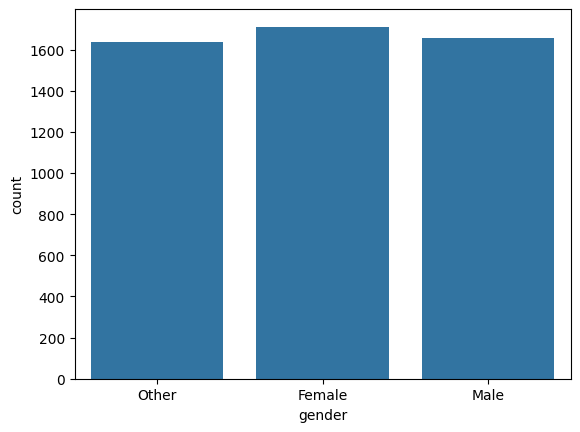

In [67]:
sns.countplot(data=df,x='gender')
plt.show()

Female users are slightly higher compared to Male and Other users.

12. get the region wise total no_of Netflix users

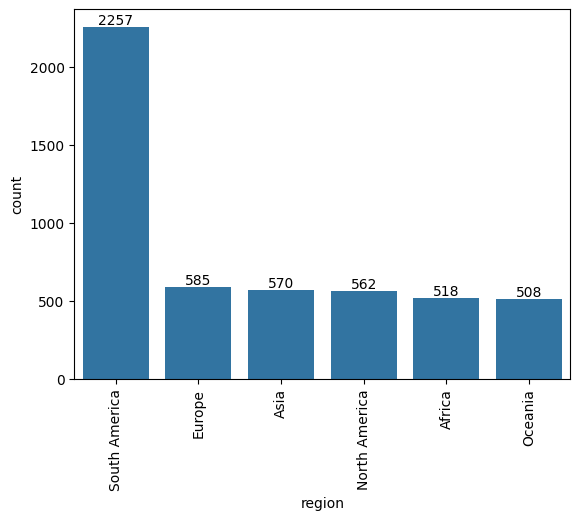

In [68]:
ax = sns.countplot(data=df,x='region',order=df['region'].value_counts().index)
for i in ax.containers:
    ax.bar_label(i)
plt.xticks(rotation=90)
plt.show()

Observation: South America has the highest number of Netflix users compared to other regions.

13. get the percentage distribution of users in each age group

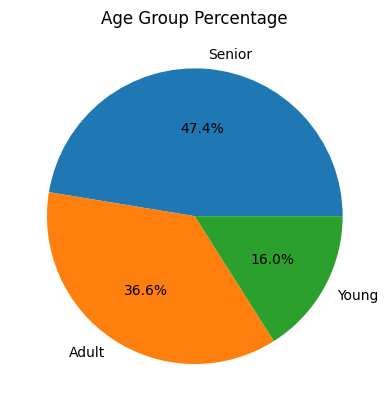

In [69]:
df['age_grp'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Age Group Percentage')
plt.show()

Observation: Senior users have the highest percentage of Netflix users, while Young users have the lowest.

14. get the total no of subscription tyee distribution

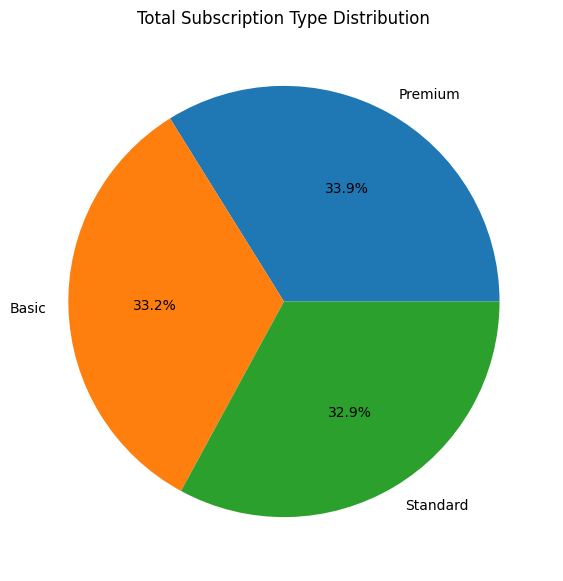

In [70]:
subscription_count = df['sub_type'].value_counts()
plt.figure(figsize=(7,7))
plt.pie(subscription_count,labels=subscription_count.index,autopct='%1.1f%%')
plt.title('Total Subscription Type Distribution')
plt.show()

Observation: All three subscription types have almost equal number of users, with Premium slightly higher.

15. get which type of profile have more no of user 

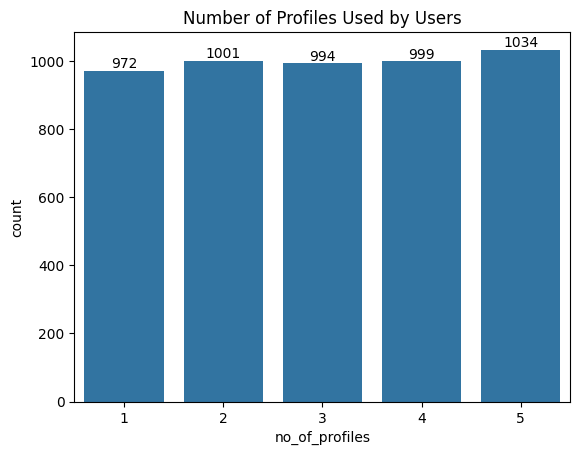

In [71]:
ax = sns.countplot(x='no_of_profiles',data=df)
ax.bar_label(ax.containers[0])
plt.title('Number of Profiles Used by Users')
plt.show()

Observation: Users with 5 profiles are slightly higher compared to other profile counts.

16. compare the average monthly fee for each subscription type

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_7644\3292673885.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sub_type',y='mon_fee',data=df,palette=['red','blue','green'])


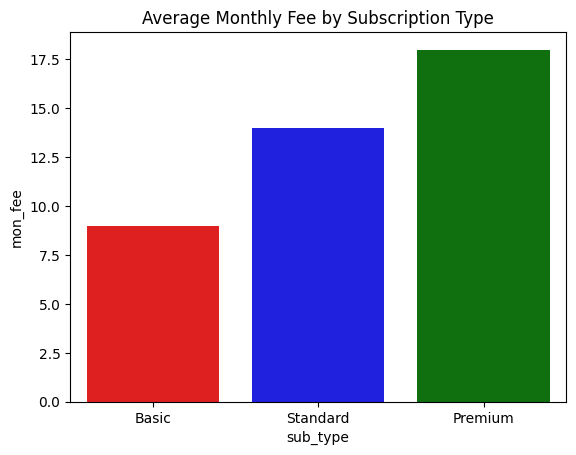

In [72]:
sns.barplot(x='sub_type',y='mon_fee',data=df,palette=['red','blue','green'])
plt.title('Average Monthly Fee by Subscription Type')
plt.show()

Observation: Premium users pay the highest monthly fee, while Basic users pay the lowest.

17. compare subscription types across different age groups

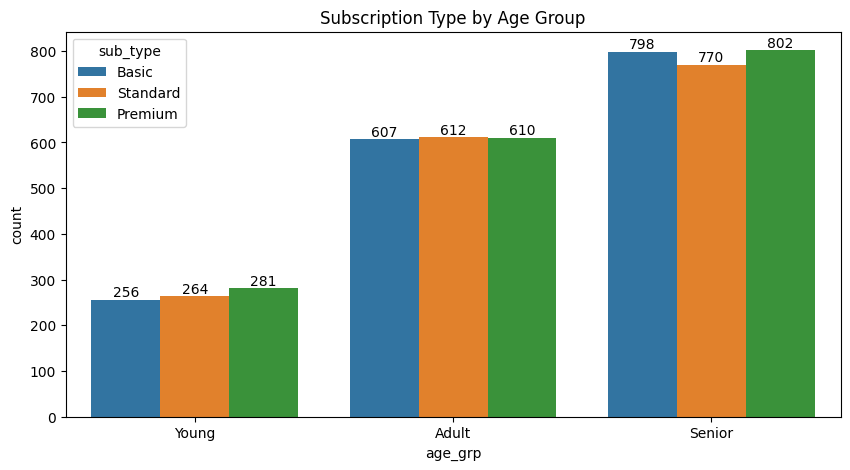

In [73]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df,x='age_grp',hue='sub_type')
plt.title('Subscription Type by Age Group')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

Observation: 

Senior users mostly prefer Premium and Basic plans, while Young users have comparatively lower subscriptions across all plans.

 Adult users show almost equal interest in Basic, Standard, and Premium subscriptions.

 Premium subscription is slightly more popular among Young and Senior users compared to Standard plans.

18. compare profile usage across age groups in different subscription plans

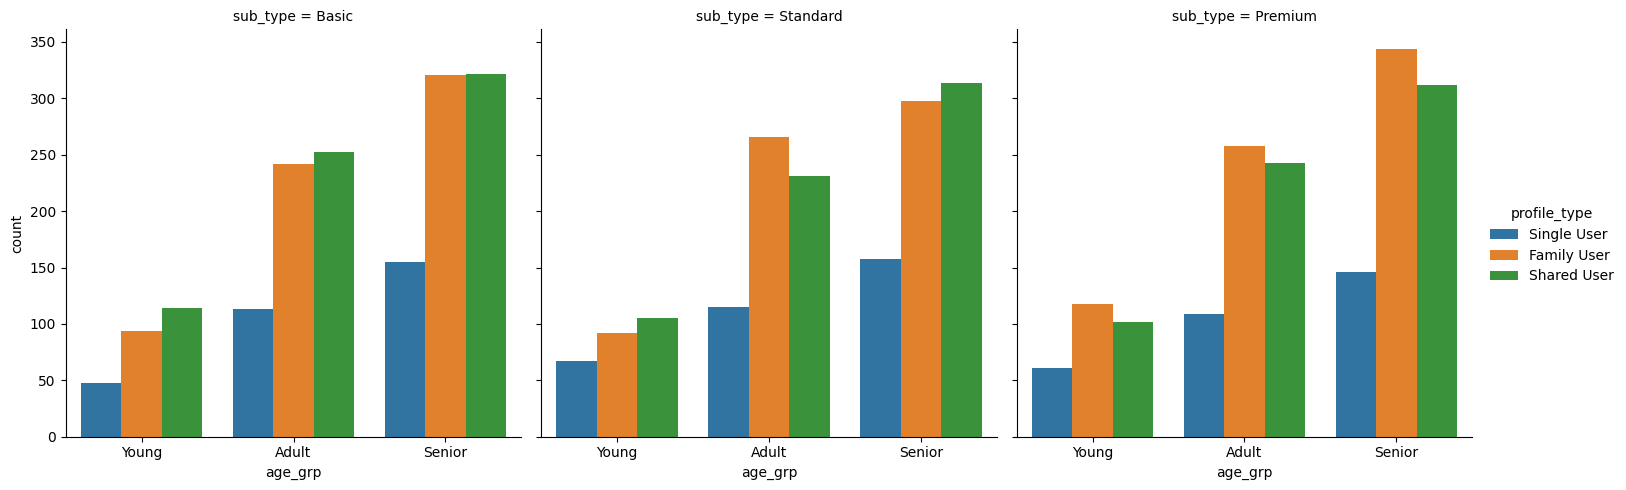

In [74]:
sns.catplot(x='age_grp',hue='profile_type',col='sub_type',data=df,kind='count')
plt.show()

Observation: 

Family User and Shared User profiles are higher among Adult and Senior users in all subscription plans.

 Single User profiles are comparatively lower than Family and Shared User profiles across every age group.

19. compare favorite genres across different age groups

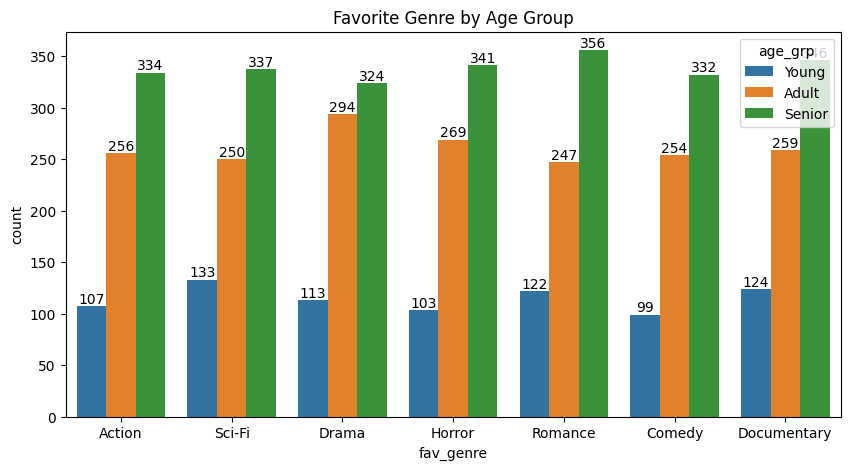

In [75]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df,x='fav_genre',hue='age_grp')
plt.title('Favorite Genre by Age Group')
for bars in ax.containers:
    ax.bar_label(bars)
plt.show()

Observation:

Senior users are highly interested in Romance and Documentary genres compared to Young users.

Drama is one of the most preferred genres among Adult users.


20. analyze the distribution of user watch hours

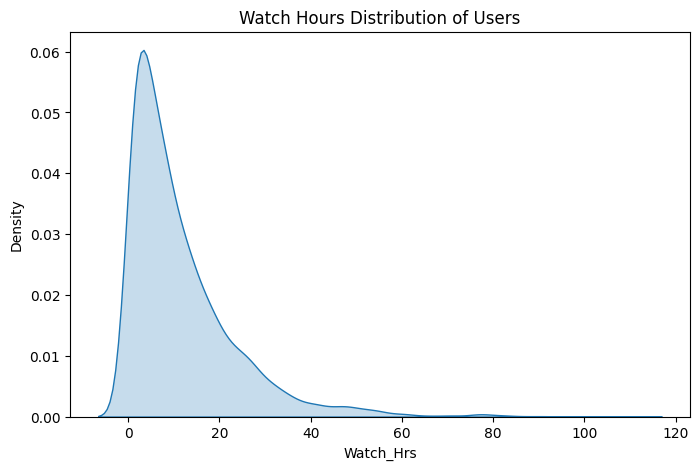

In [76]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['watch_hrs'],fill=True)
plt.title('Watch Hours Distribution of Users')
plt.xlabel('Watch_Hrs')
plt.ylabel('Density')
plt.show()

observation: Most Netflix users spend less watch time, while only a few users spend very high watch hours.

skewness:

watch hours is fully right skewed



21. compare watch hours across different age groups

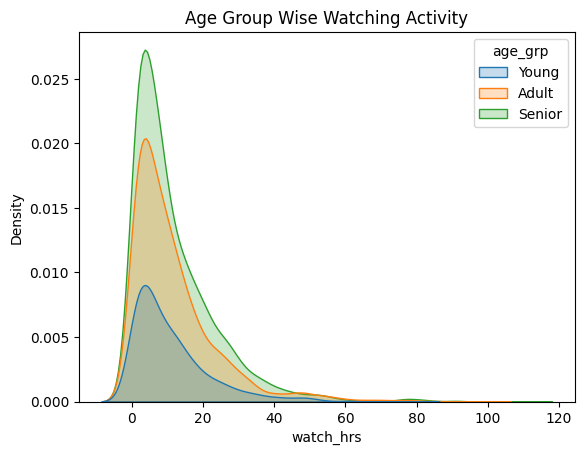

In [77]:
sns.kdeplot(data=df,x='watch_hrs',hue='age_grp',fill=True)
plt.title('Age Group Wise Watching Activity')
plt.show()

Observation: 

Senior users spend more watch hours on Netflix compared to Young users,Only a small number of users from each age group spend very high watch hours.

22. compare watching habits across different age groups

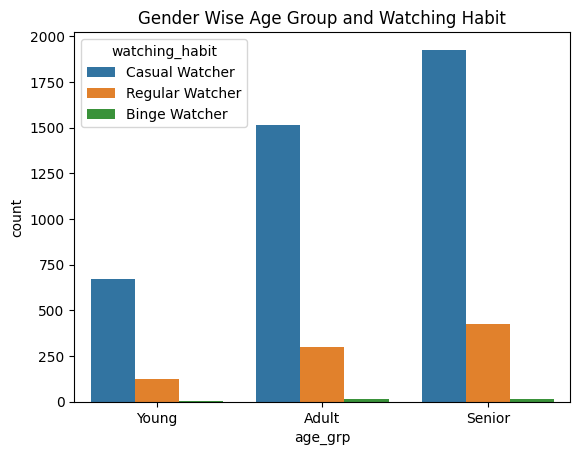

In [78]:
sns.countplot(x='age_grp',hue='watching_habit',data=df)
plt.title('Gender Wise Age Group and Watching Habit')
plt.show()

Observation: 

Casual Watchers are the highest in all age groups compared to Regular and Binge Watchers.

Watching activity gradually increases from Young users to Senior users.

23. compare activity status across different age groups

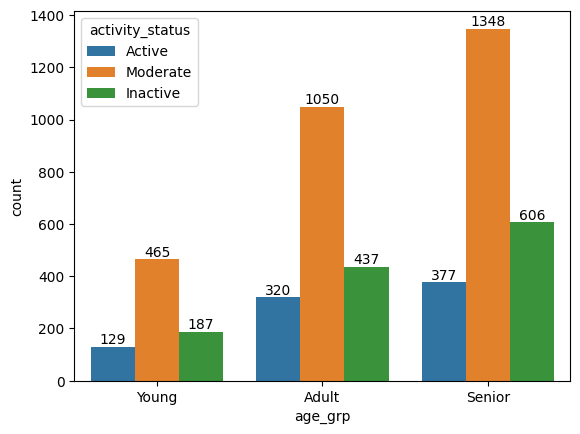

In [79]:
ax = sns.countplot(x='age_grp',hue='activity_status',data=df)
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
ax.bar_label(ax.containers[2])
plt.show()

Observation: 

Inactive users are higher among Senior users compared to Young users.

24. count the lost and retained user based on the Subscription type

In [80]:
pd.crosstab(df['sub_type'],df['churn'])

churn,0,1
sub_type,,
Basic,634,1027
Premium,953,740
Standard,898,748


25. compare churned and non-churned customers across subscription plans

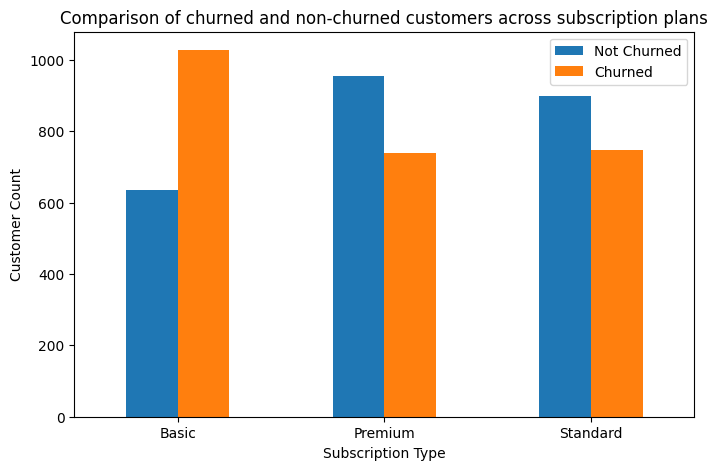

In [81]:
churn_chart = pd.crosstab(df['sub_type'],df['churn'])
churn_chart.plot(kind='bar',figsize=(8,5))
plt.title('Comparison of churned and non-churned customers across subscription plans')
plt.xlabel('Subscription Type')
plt.ylabel('Customer Count')
plt.xticks(rotation=0)
plt.legend(['Not Churned','Churned'])
plt.show()

Observation: 

Customer churn is highest among users with Basic subscription plans.

26. compare retained and lost customers across age groups based on login days

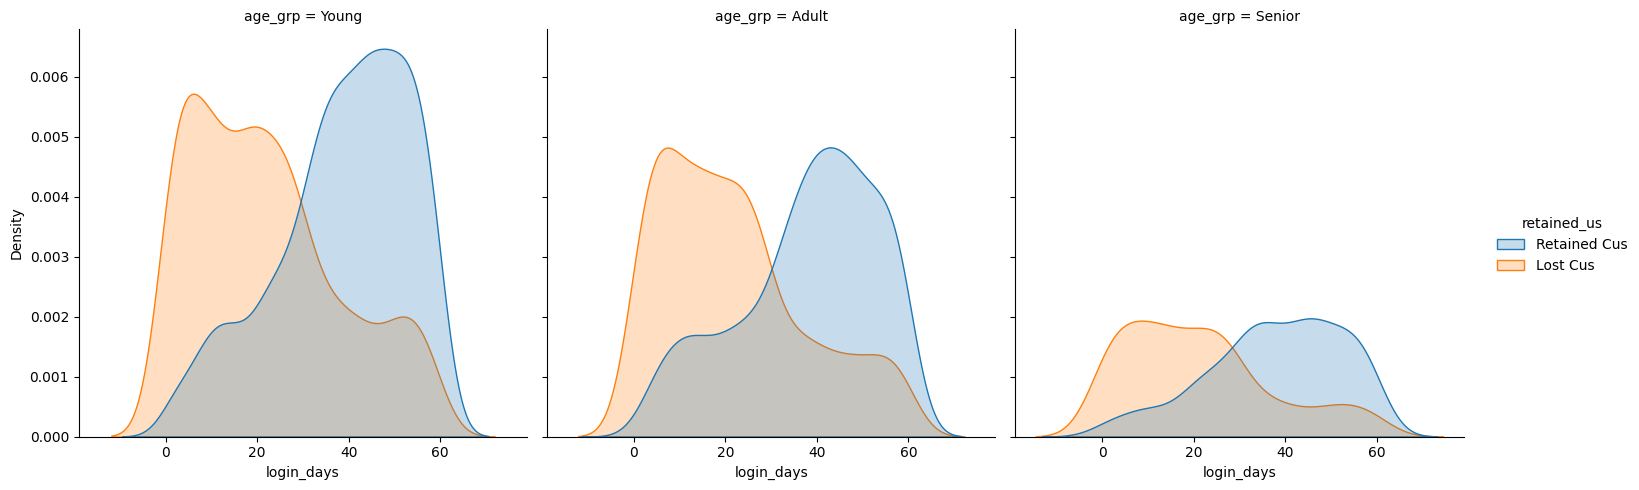

In [82]:
sns.displot(data=df,x='login_days',hue='retained_us',col='age_grp',kind='kde',fill=True)
plt.show()

Observation: 

Retained customers generally have higher login activity compared to lost customers across all age groups.

26. plot the correlation no of profiles,watch hours,login days,churn

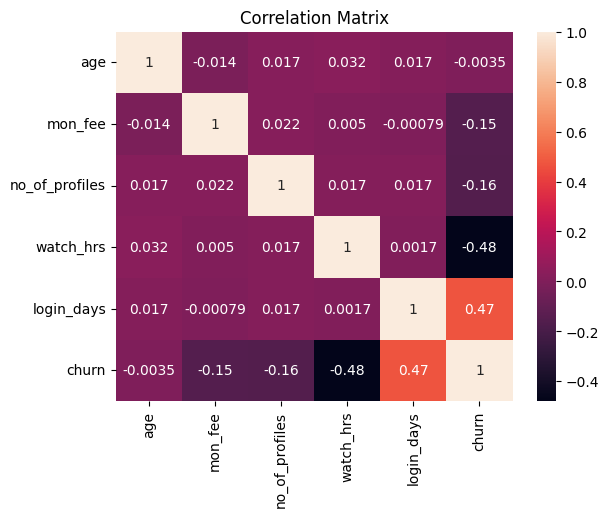

In [83]:
corr = df[['age','mon_fee','no_of_profiles','watch_hrs','login_days','churn']].corr()
sns.heatmap(corr, annot=True)
plt.title('Correlation Matrix')
plt.show()

observation:

Watch hours have a highly negative correlation with churn

Login days show a positive correlation with churn

Monthly fee and number of profiles have a slight negative relationship with churn

## Conclution

1. user activity, watch hours, subscription type, and login behavior are the major factors affecting customer retention and churn in Netflix.

2. Users with lower watch hours and higher inactivity days are more likely to become churned customers.

3. Premium and Standard subscription users show better retention compared to Basic subscription users.

4. Senior and Adult users are more active on Netflix, with higher watch hours, subscription counts, and engagement levels.

5. Overall, user engagement and regular platform activity are the key factors affecting customer retention